# K-means pathway clustering — single Parcels store

Prototype: cluster the trajectories of **one** `Parcels_run_*.zarr` by the route they take.

Note: one store = one release date, so this is a single season. The goal here is only to get the
pathway-clustering working. Seasonal comparison comes later, by running this over many release dates
and cross-tabulating the cluster labels against `start_season`.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 1. Load one store

In [2]:
store = "/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-06 00:00:00.zarr"

ds = xr.open_zarr(store).drop_vars(["z", "sal", "temp"])

# trim trailing obs steps where no particle has data
num_valid = int(ds.lat.notnull().any("trajectory").sum().compute().data[()])
ds = ds.isel(obs=slice(0, num_valid))
ds

<xarray.Dataset> Size: 178MB
Dimensions:     (trajectory: 10000, obs: 741)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 59MB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float64 59MB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 59MB dask.array<chunksize=(10000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

## 2. Build one feature vector per trajectory

Subsample each path to `N` points along `obs` and flatten to `[lon_0..lon_{N-1}, lat_0..lat_{N-1}]`.
Trailing NaNs (particle left the domain / was deleted) are forward-filled, so a path that stops
is treated as staying at its last position. Trajectories with no valid start are dropped.

In [3]:
N = 400  # number of points sampled along each path
obs_idx = np.linspace(0, ds.sizes["obs"] - 1, N).astype(int)

lon = ds.lon.isel(obs=obs_idx).compute().values  # (trajectory, N)
lat = ds.lat.isel(obs=obs_idx).compute().values

# forward-fill trailing NaNs along the path
lon = pd.DataFrame(lon).ffill(axis=1).values
lat = pd.DataFrame(lat).ffill(axis=1).values

# keep only fully-valid paths
valid = np.isfinite(lon).all(1) & np.isfinite(lat).all(1)
lon, lat = lon[valid], lat[valid]
traj_ids = ds.trajectory.values[valid]
print(f"{valid.sum()} / {valid.size} trajectories kept")

X = np.hstack([lon, lat])           # (n_traj, 2N)
Xs = StandardScaler().fit_transform(X)
Xs.shape

10000 / 10000 trajectories kept


(10000, 800)

## 3. K-means

In [4]:
k = 15
km = KMeans(n_clusters=k, n_init=10, random_state=0)
labels = km.fit_predict(Xs)

pd.Series(labels).value_counts().sort_index()

0      738
1      492
2     1084
3      592
4     1082
5      442
6     1190
7      333
8      569
9      140
10    1564
11     846
12      42
13     264
14     622
Name: count, dtype: int64

## 4. Plot the clustered pathways

A random subsample of trajectories per cluster, coloured by cluster label.

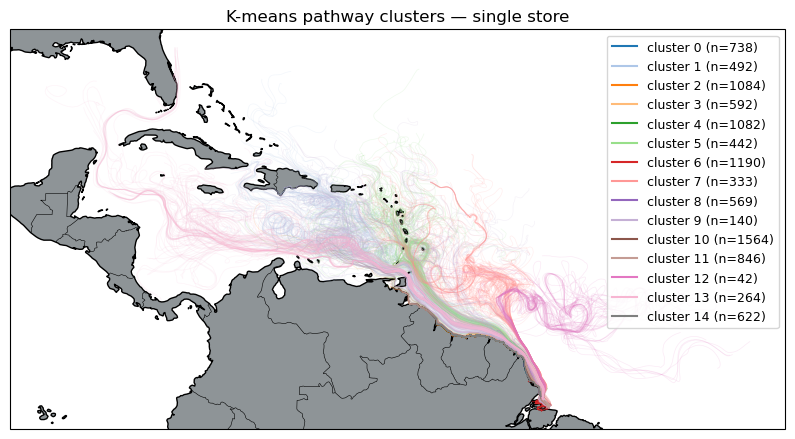

In [5]:
rng = np.random.default_rng(0)
per_cluster = 100  # trajectories drawn per cluster for the plot
colors = plt.cm.tab20(np.arange(k))

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

for c in range(k):
    idx = np.where(labels == c)[0]
    if idx.size > per_cluster:
        idx = rng.choice(idx, per_cluster, replace=False)
    ax.plot(lon[idx].T, lat[idx].T, color=colors[c], alpha=0.15, linewidth=0.5,
            transform=ccrs.PlateCarree())
    # one labelled line for the legend
    ax.plot([], [], color=colors[c], label=f"cluster {c} (n={np.sum(labels==c)})")

ax.coastlines(resolution="50m")
ax.add_feature(cf.LAND, facecolor="#8e9497", zorder=0)
ax.add_feature(cf.BORDERS, linewidth=0.4)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("K-means pathway clusters — single store")
plt.show()

## 5. Cluster-mean pathways

The centroid path of each cluster (the average route).

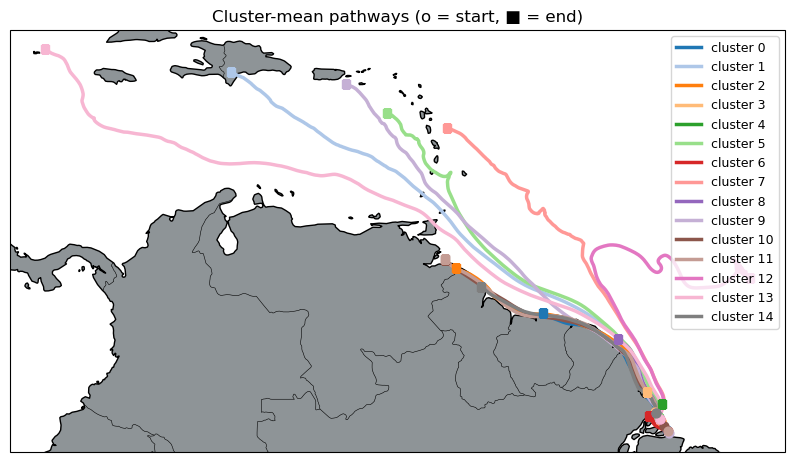

In [6]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

for c in range(k):
    mlon = lon[labels == c].mean(0)
    mlat = lat[labels == c].mean(0)
    ax.plot(mlon, mlat, color=colors[c], linewidth=2.5,
            transform=ccrs.PlateCarree(), label=f"cluster {c}")
    ax.scatter(mlon[0], mlat[0], color=colors[c], marker="o", s=40,
               transform=ccrs.PlateCarree(), zorder=5)  # start
    ax.scatter(mlon[-1], mlat[-1], color=colors[c], marker="s", s=40,
               transform=ccrs.PlateCarree(), zorder=5)  # end

ax.coastlines(resolution="50m")
ax.add_feature(cf.LAND, facecolor="#8e9497", zorder=0)
ax.add_feature(cf.BORDERS, linewidth=0.4)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Cluster-mean pathways (o = start, ■ = end)")
plt.show()

## 6. Time Weighted 

In [8]:
ds = ds.compute()
ds

<xarray.Dataset> Size: 178MB
Dimensions:     (trajectory: 10000, obs: 741)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 59MB 0.2145 0.2162 ... 20.24 nan
    lon         (trajectory, obs) float64 59MB -49.28 -49.27 ... -67.37 nan
    time        (trajectory, obs) datetime64[ns] 59MB 1993-01-06 ... NaT
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [68]:
time_count = (ds.time - ds.time.isel(obs=0)).astype('float64') / (86400 * 1e9)
time_count = time_count.where(ds.time.notnull())   # mask NaT instead of guessing -200
ds['time_count'] = time_count
ds

<xarray.Dataset> Size: 237MB
Dimensions:     (trajectory: 10000, obs: 741)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 59MB 0.2145 0.2162 ... 20.24 nan
    lon         (trajectory, obs) float64 59MB -49.28 -49.27 ... -67.37 nan
    time        (trajectory, obs) datetime64[ns] 59MB 1993-01-06 ... NaT
    time_count  (trajectory, obs) float64 59MB 0.0 0.25 0.5 ... 184.5 184.8 nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2